# Forces and structural relaxation

The force is `jax.grad` of the total energy with respect to the atomic positions, taken
at **frozen** wavefunctions, occupations and eigenvalues — Hellmann-Feynman, Pulay and the
augmentation charge's own derivative all falling out of one gradient, with nothing
hand-derived. QE's six force routines are transcribed beside it as a cross-check, and the
two agree with `pw.x` to **≤2e-5 Ry/bohr** on five references; a BFGS relaxation
reproduces QE's geometry to **1e-6 bohr**.

The force is a *partial* derivative -- the states are held fixed, which is what makes it
Hellmann-Feynman plus Pulay rather than a chain rule through the whole SCF:

$$\mathbf F_I = -\left.\frac{\partial E_{\rm tot}
   [\{\psi\}, \{f\}, \boldsymbol\tau]}
   {\partial \boldsymbol\tau_I}\right|_{\psi,\, f,\, \varepsilon\ \rm fixed}$$

The energy is stationary in the wavefunctions at the converged state, so freezing them
loses nothing; the terms QE derives by hand -- `force_lc`, `force_cc`, `force_ew`,
`force_us`, `addusforce`, `force_corr` -- are what this one derivative expands into.

Phase P15. Inputs and references are committed under `tests/data/qe/`.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.forces import compute_forces, frozen_energy, state_from_result
from pypresso.io import read_qe_output
from pypresso.scf import run_scf          # the finite difference below needs it

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")


def load(case):
    return Calculator.from_file(CASES / f"{case}.in", pseudo_dir=PSEUDO,
                                announce=False, conv_thr=1e-10)


def reference(case):
    return read_qe_output(CASES / f"reference.out.{case}")


# The gate: the functional that gets differentiated must *be* the total energy at the
# converged state. If it is not, its derivative is the force of some other calculation --
# and every term below would still look plausible.
print("%-18s %18s %18s %12s"
      % ("case", "SCF total (Ry)", "frozen functional", "difference"))
for case in ("si2-nc-force", "si2-us-force", "si2-paw-force", "si2-us-pbe-force"):
    calc = load(case)
    scf = calc.get_scf()
    energy = float(frozen_energy(calc.calculation,
                                 calc.system.structure.positions,
                                 state_from_result(scf)))
    print("%-18s %18.10f %18.10f %12.1e"
          % (case, scf.total_energy, energy, energy - scf.total_energy))

case                   SCF total (Ry)  frozen functional   difference


si2-nc-force           -15.7874037087     -15.7874037087      1.8e-15


si2-us-force           -22.7454400458     -22.7454400458      3.6e-15


si2-paw-force          -89.2668867248     -89.2668867248      1.0e-12


si2-us-pbe-force       -22.8143892008     -22.8143892008      0.0e+00


## The force on a displaced silicon cell

Two atoms pushed off their sites, so there is a force to compute at all. Against QE, and
against a finite difference of the SCF energy itself — the check that trusts neither
implementation, run with symmetry switched off so that nothing is projected out.

In [2]:
import dataclasses

calc = load("si2-nc-force")
forces = calc.get_forces()                       # autodiff, the default
qe = reference("si2-nc-force")

print("%4s %38s %38s" % ("atom", "pypresso (Ry/bohr)", "Quantum ESPRESSO"))
for atom, (ours, theirs) in enumerate(zip(forces.forces, qe.forces)):
    print("%4d  %s   %s" % (atom, " ".join("% .8f" % v for v in ours),
                            " ".join("% .8f" % v for v in theirs)))
print("largest difference %.2e Ry/bohr" % np.abs(forces.forces - qe.forces).max())

nosym = Calculator(dataclasses.replace(calc.system, nosym=True), calc.pseudos,
                   announce=False, conv_thr=1e-12)
autodiff = nosym.get_forces().forces

# The finite difference is of the *same* fixed setup, so it steps the positions
# through `at_positions` rather than building a new calculator each time: that is
# what keeps the basis frozen and the difference free of Pulay error.
plain, pseudos = nosym.calculation, nosym.pseudos


def energy_at(positions):
    moved = plain.at_positions(jnp.asarray(positions))
    return run_scf(moved.system, pseudos, calculation=moved, conv_thr=1e-12).total_energy


h, origin = 2.0e-3, np.asarray(nosym.system.structure.positions)
print("\n%12s %20s %16s %13s"
      % ("coordinate", "finite difference", "autodiff", "difference"))
for atom, direction in ((0, 0), (0, 1), (1, 2)):
    plus, minus = origin.copy(), origin.copy()
    plus[atom, direction] += h
    minus[atom, direction] -= h
    fd = -(energy_at(plus) - energy_at(minus)) / (2 * h)
    print("  atom %d %s   %20.8f %16.8f %13.1e"
          % (atom, "xyz"[direction], fd, autodiff[atom, direction],
             fd - autodiff[atom, direction]))

atom                     pypresso (Ry/bohr)                       Quantum ESPRESSO
   0   0.06039736 -0.00000000  0.00000000    0.06039673  0.00000000  0.00000000
   1  -0.06039736  0.00000000 -0.00000000   -0.06039673  0.00000000  0.00000000
largest difference 6.26e-07 Ry/bohr



  coordinate    finite difference         autodiff    difference


  atom 0 x             0.06076082       0.06076358      -2.8e-06


  atom 0 y            -0.00470094      -0.00470190       9.5e-07


  atom 1 z             0.01005466       0.01005364       1.0e-06


## The same force, the way Quantum ESPRESSO computes it

`force_lc`, `force_cc`, `force_ew`, `force_us`, `addusforce` and `force_corr`,
transcribed behind the same registry. The two implementations share no machinery, which
is what makes the comparison worth having: it is what found the augmentation force's sign
and the gradient correction missing from `force_cc`.

They differ by exactly one term. `force_corr` is a correction for the density not being
quite converged, which the gradient does not have because it differentiates the energy
*of the state it was given*; it vanishes as `conv_thr` tightens, and at 1e-10 Ry it is
already down at 1e-7 Ry/bohr.

In [3]:
us = load("si2-us-force")
system_us, calc_us = us.system, us.calculation
qe_us = reference("si2-us-force")

analytic = us.get_forces(method="analytic")
autodiff_us = us.get_forces(method="autodiff")

from pypresso.system.symmetry import atom_mapping, symmetrize_vector

mapping = atom_mapping(system_us.cell, system_us.structure, calc_us.symmetries)
terms = dict(analytic.terms)
terms["nonlocal"] = terms["nonlocal"] + terms.pop("augmentation")     # QE folds it in

print("%16s %22s %20s %12s"
      % ("term", "pypresso (x, atom 1)", "Quantum ESPRESSO", "difference"))
for name, qe_name in (("ewald", "ionic"), ("local", "local"), ("core", "core"),
                      ("nonlocal", "nonlocal"), ("scf_correction", "scf_correction")):
    ours = np.asarray(symmetrize_vector(np.asarray(terms[name]), system_us.cell,
                                        calc_us.symmetries, mapping))
    theirs = qe_us.force_terms[qe_name]
    print("%16s %22.8f %20.8f %12.1e"
          % (name, ours[0, 0], theirs[0, 0], np.abs(ours - theirs).max()))
print("\ntotal, analytic vs QE   %.1e Ry/bohr"
      % np.abs(analytic.forces - qe_us.forces).max())
print("total, autodiff vs QE   %.1e Ry/bohr"
      % np.abs(autodiff_us.forces - qe_us.forces).max())

            term   pypresso (x, atom 1)     Quantum ESPRESSO   difference
           ewald             0.10209222           0.10209221      1.1e-08
           local            -0.10042023          -0.10042054      3.1e-07
            core            -0.00600309          -0.00600313      4.5e-08
        nonlocal             0.06307452           0.06307509      5.7e-07
  scf_correction             0.00000007          -0.00000028      4.0e-07

total, analytic vs QE   2.0e-07 Ry/bohr
total, autodiff vs QE   1.3e-07 Ry/bohr


## Relaxation

`calculation = 'relax'` runs QE's BFGS with its trust radius and Wolfe line search, in
crystal coordinates with the cell metric. The setup — FFT grid, symmetry group, k-points
— is done **once** and only checked afterwards, which is why a relaxation cannot change
the symmetry of the crystal and `checkallsym` complains if the geometry tries to.

 step    total energy (Ry)   max |F| (Ry/bohr)   separation (alat)
    1         -15.78740371            0.060397   (0.2700, 0.2500, 0.2500)
    2         -15.79256155            0.024847   (0.2582, 0.2500, 0.2500)
    3         -15.79359588            0.000366   (0.2499, 0.2500, 0.2500)
    4         -15.79359610            0.000001   (0.2500, 0.2500, 0.2500)

final energy   pypresso -15.7935961045   QE -15.7935961042   difference -2.8e-10 Ry
final geometry differs from QE by 3.4e-07 bohr


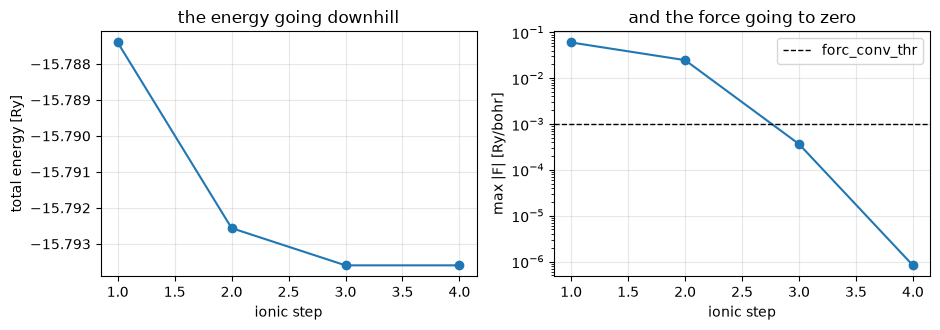

In [4]:
relax = load("si2-nc-relax")
relaxed = relax.get_relax()
qe_relax = reference("si2-nc-relax")
alat = float(relax.system.cell.alat)

print("%5s %20s %19s %19s" % ("step", "total energy (Ry)", "max |F| (Ry/bohr)",
                              "separation (alat)"))
for step in relaxed.steps:
    separation = (step.positions[1] - step.positions[0]) / alat
    print("%5d %20.8f %19.6f   (%.4f, %.4f, %.4f)"
          % (step.index, step.total_energy, step.max_force, *separation))
print("\nfinal energy   pypresso %.10f   QE %.10f   difference %.1e Ry"
      % (relaxed.total_energy, qe_relax.final_energy,
         relaxed.total_energy - qe_relax.final_energy))
print("final geometry differs from QE by %.1e bohr"
      % np.abs(relaxed.positions - qe_relax.final_positions).max())

fig, (left, right) = plt.subplots(1, 2, figsize=(9.5, 3.4))
steps = [s.index for s in relaxed.steps]
left.plot(steps, [s.total_energy for s in relaxed.steps], "o-")
left.set_xlabel("ionic step"); left.set_ylabel("total energy [Ry]")
left.set_title("the energy going downhill"); left.grid(alpha=0.3)
right.semilogy(steps, [max(s.max_force, 1e-12) for s in relaxed.steps], "o-")
right.axhline(1e-3, ls="--", c="k", lw=1, label="forc_conv_thr")
right.set_xlabel("ionic step"); right.set_ylabel("max |F| [Ry/bohr]")
right.set_title("and the force going to zero"); right.legend(); right.grid(alpha=0.3)
fig.tight_layout()

QE's own CO relaxation runs here too, with the oxygen frozen by `if_pos` — its input is
in the vendored tree (`pw_relax/relax.in`) and the regression test carries it.

---
**The detail:** `PLAN.md` §3 P15 — why the force is a *partial* derivative, the
orthonormality constraint that makes ultrasoft's Pulay term part of the same gradient,
and the three traps (the Ewald neighbour list belongs to the cell and not the geometry;
`gradcorr` is called from inside `v_xc`, so `force_cc` needs it; `symvector` is not
optional).
**The tests:** `tests/regression/test_forces.py`, `tests/regression/test_relax.py`,
`tests/unit/test_force_machinery.py`.